Problem Description:
Customer support teams receive a large volume of unstructured email tickets containing diverse issues such as technical problems, service requests, and complaints. Manually analyzing and routing these emails is time-consuming, error-prone, and inefficient, especially at scale.

This project aims to build an NLP-driven system that automatically converts raw email text into structured insights by performing multi-task classification and semantic retrieval.[link](https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets)

# Preprocessing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

In [5]:
from datasets import load_dataset

dataset = load_dataset("Tobi-Bueck/customer-support-tickets", split="train")
df = pd.DataFrame(dataset)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [6]:
df = df[df['language'] == 'en']
df = df.drop(columns=['language', 'version'])
df.reset_index(drop=True, inplace=True)

In [7]:
tag_cols = [f'tag_{i}' for i in range(1,9)]
df['tags'] = df[tag_cols].values.tolist()
df['tags'] = df['tags'].apply(lambda x: [t for t in x if t is not None])
df = df.drop(columns=tag_cols)

# Combine subject + body
df['text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')
df = df.drop(columns=['subject', 'body'])

In [8]:
print(df.info())
print(df.describe(include='all'))

# Count unique classes
for col in ['type','queue','priority']:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28261 entries, 0 to 28260
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   answer    28255 non-null  object
 1   type      28261 non-null  object
 2   queue     28261 non-null  object
 3   priority  28261 non-null  object
 4   tags      28261 non-null  object
 5   text      28261 non-null  object
dtypes: object(6)
memory usage: 1.3+ MB
None
                                                   answer      type  \
count                                               28255     28261   
unique                                              23619         4   
top     received an email about the data breach in the...  Incident   
freq                                                    2     11213   

                    queue priority                                  tags  \
count               28261    28261                                 28261   
unique                 10        3 

In [9]:
print(df.isnull().sum())

answer      6
type        0
queue       0
priority    0
tags        0
text        0
dtype: int64


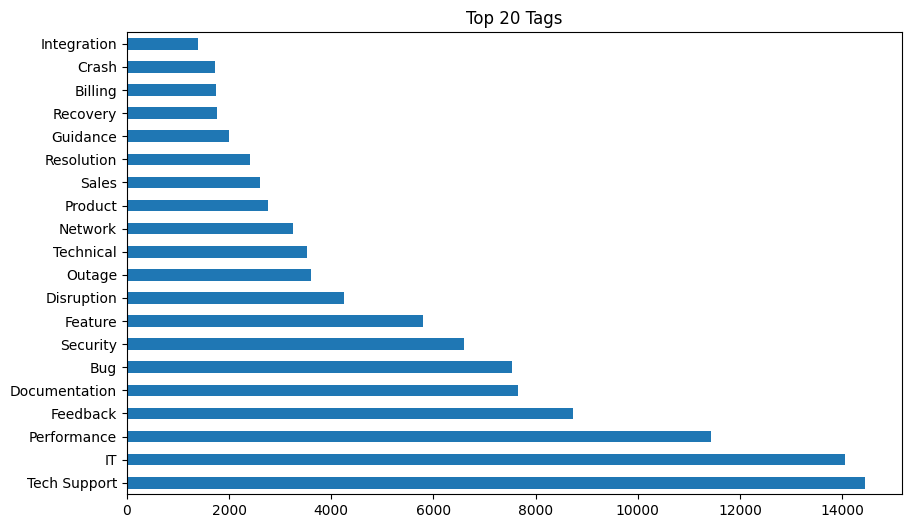

In [10]:
all_tags = [t for tags in df['tags'] for t in tags]
tags_series = pd.Series(all_tags)
tags_series.value_counts().head(20).plot(kind='barh', figsize=(10,6))
plt.title("Top 20 Tags")
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

le_type = LabelEncoder()
le_priority = LabelEncoder()
le_queue = LabelEncoder()

df['type_enc'] = le_type.fit_transform(df['type'])
df['priority_enc'] = le_priority.fit_transform(df['priority'])
df['queue_enc'] = le_queue.fit_transform(df['queue'])

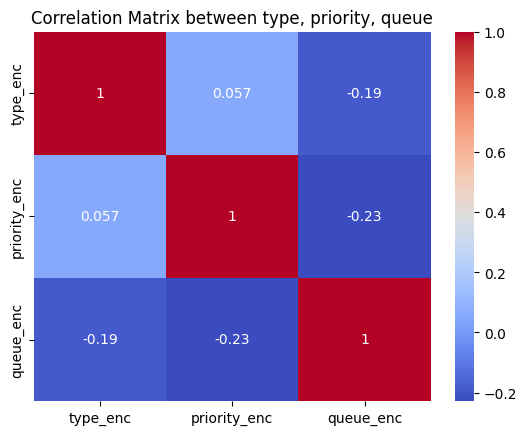

In [12]:
corr_cols = ['type_enc','priority_enc','queue_enc']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix between type, priority, queue")
plt.show()

In [13]:
combinations = list(product(df['type'].unique(), df['priority'].unique(), df['queue'].unique()))
comb_df = pd.DataFrame(combinations, columns=['type','priority','queue'])

# Merge with counts in dataset
counts = df.groupby(['type','priority','queue']).size().reset_index(name='count')
comb_df = comb_df.merge(counts, on=['type','priority','queue'], how='left').fillna(0)
comb_df.head(10)

,type,priority,queue,count
0,Incident,high,Technical Support,2487
1,Incident,high,Returns and Exchanges,115
2,Incident,high,Billing and Payments,209
3,Incident,high,Sales and Pre-Sales,18
4,Incident,high,Service Outages and Maintenance,420
5,Incident,high,Product Support,724
6,Incident,high,IT Support,579
7,Incident,high,Customer Service,214
8,Incident,high,Human Resources,32
9,Incident,high,General Inquiry,36


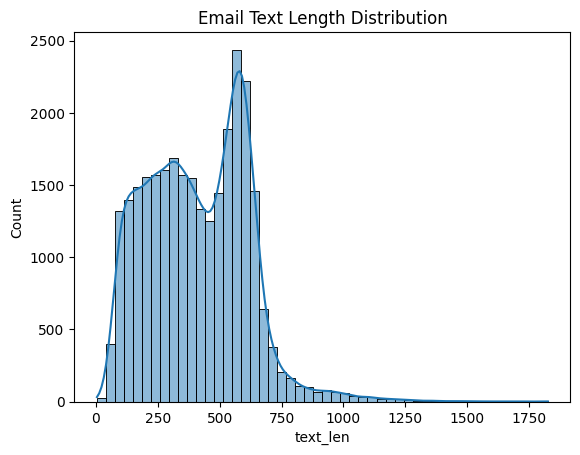

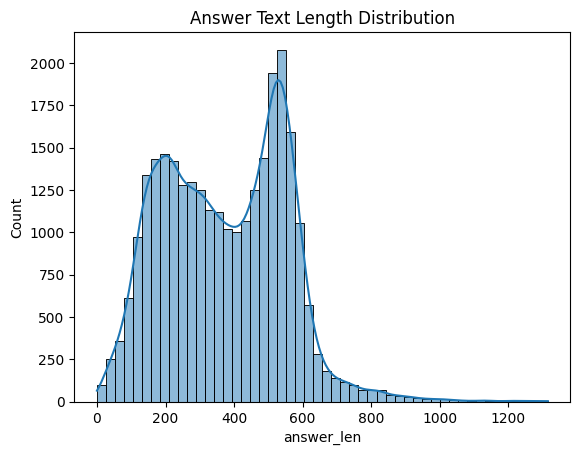

In [14]:
df['text_len'] = df['text'].apply(len)
df['answer_len'] = df['answer'].fillna('').apply(len)

sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Email Text Length Distribution")
plt.show()

sns.histplot(df['answer_len'], bins=50, kde=True)
plt.title("Answer Text Length Distribution")
plt.show()

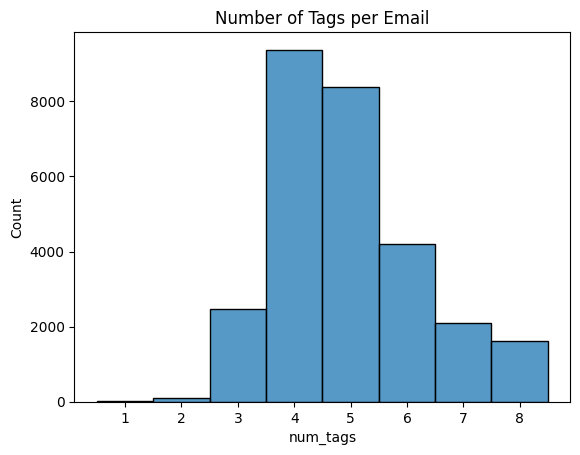

In [15]:
df['num_tags'] = df['tags'].apply(len)
sns.histplot(df['num_tags'], bins=8, discrete=True)
plt.title("Number of Tags per Email")
plt.show()

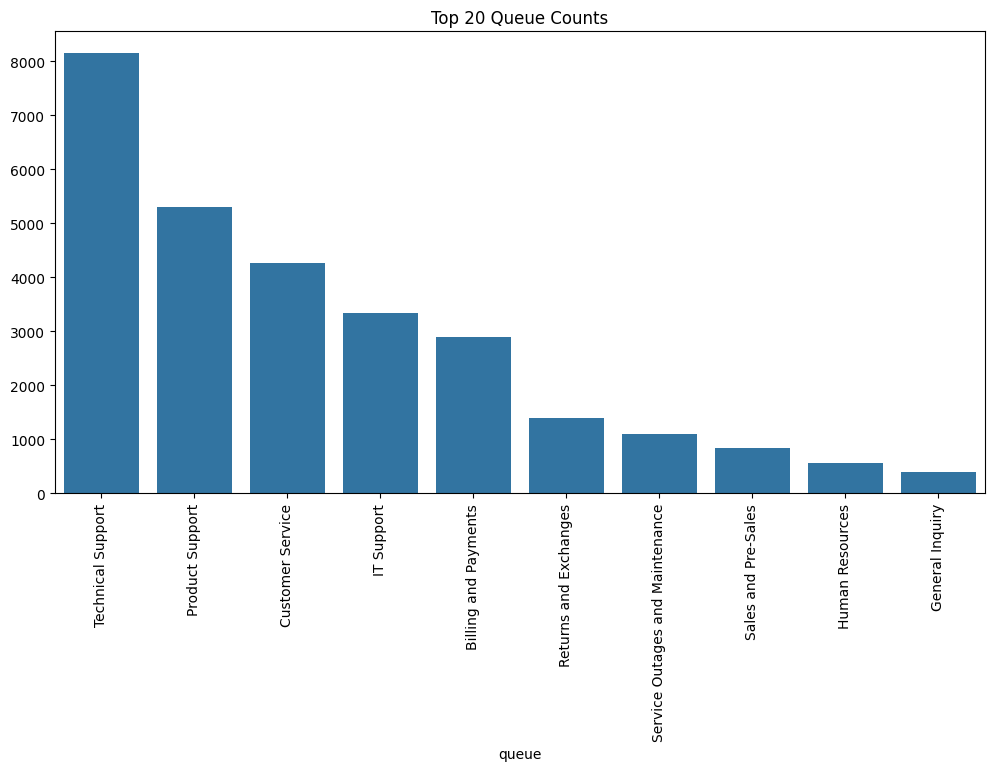

In [16]:
queue_counts = df['queue'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=queue_counts.index[:20], y=queue_counts.values[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Queue Counts")
plt.show()

In [17]:
from collections import Counter
tag_combos = df['tags'].apply(lambda x: tuple(sorted(x)))
Counter(tag_combos).most_common(10)

[(('Bug', 'IT', 'Performance', 'Tech Support'), 1049),
 (('Feedback', 'IT', 'Sales', 'Tech Support'), 525),
 (('Documentation', 'Feature', 'IT', 'Tech Support'), 476),
 (('Documentation', 'IT', 'Security', 'Tech Support'), 435),
 (('Bug', 'IT', 'Network', 'Performance', 'Tech Support'), 417),
 (('Feature', 'Feedback', 'IT', 'Tech Support'), 397),
 (('IT', 'Network', 'Performance', 'Tech Support'), 360),
 (('Documentation', 'Feature', 'Feedback', 'IT', 'Tech Support'), 326),
 (('Bug', 'Crash', 'IT', 'Performance', 'Tech Support'), 309),
 (('Bug', 'Documentation', 'IT', 'Performance', 'Tech Support'), 309)]

In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+',' ', text)
    text = re.sub(r'[^a-z0-9 .,?!]', '', text)
    return text

df['text_clean'] = df['text'].apply(clean_text)
df['answer_clean'] = df['answer'].fillna('').apply(clean_text)

In [19]:
df.to_csv("customer_support_cleaned.csv", index=False)

# TEST_TRAIN

In [20]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['type'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [21]:
!pip install sentence-transformers

In [22]:
# Cell 18: Embedding-based features
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
X_train = embed_model.encode(
    train_df['text_clean'].tolist(),
    show_progress_bar=True
)

X_test = embed_model.encode(
    test_df['text_clean'].tolist(),
    show_progress_bar=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/707 [00:00<?, ?it/s]

Batches:   0%|          | 0/177 [00:00<?, ?it/s]

In [23]:
y_train_type = train_df['type']
y_test_type = test_df['type']

In [24]:
y_train_priority = train_df['priority']
y_test_priority = test_df['priority']

In [25]:
y_train_queue = train_df['queue']
y_test_queue = test_df['queue']

In [26]:
from sklearn.linear_model import LogisticRegression

type_model = LogisticRegression(max_iter=1000)
type_model.fit(X_train, y_train_type)

LogisticRegression(max_iter=1000)

In [27]:
priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train, y_train_priority)

LogisticRegression(max_iter=1000)

In [28]:
queue_model = LogisticRegression(max_iter=1000, class_weight='balanced')
queue_model.fit(X_train, y_train_queue)

LogisticRegression(class_weight='balanced', max_iter=1000)

# Evaluation metrix

In [29]:
from sklearn.metrics import classification_report

# TYPE
print("TYPE MODEL")
print(classification_report(y_test_type, type_model.predict(X_test)))

# PRIORITY
print("PRIORITY MODEL")
print(classification_report(y_test_priority, priority_model.predict(X_test)))

# QUEUE
print("QUEUE MODEL")
print(classification_report(y_test_queue, queue_model.predict(X_test)))

TYPE MODEL
              precision    recall  f1-score   support

      Change       0.96      0.88      0.92       598
    Incident       0.72      0.89      0.79      2243
     Problem       0.61      0.33      0.43      1179
     Request       0.95      0.99      0.97      1633

    accuracy                           0.80      5653
   macro avg       0.81      0.77      0.78      5653
weighted avg       0.79      0.80      0.78      5653

PRIORITY MODEL
              precision    recall  f1-score   support

        high       0.54      0.53      0.54      2180
         low       0.42      0.10      0.16      1143
      medium       0.47      0.66      0.55      2330

    accuracy                           0.50      5653
   macro avg       0.48      0.43      0.41      5653
weighted avg       0.49      0.50      0.47      5653

QUEUE MODEL
                                 precision    recall  f1-score   support

           Billing and Payments       0.74      0.69      0.71       596

In [30]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y_train_tags = mlb.fit_transform(train_df['tags'])
y_test_tags = mlb.transform(test_df['tags'])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['2019', 'AES', 'Access Restriction', 'Accrual', 'AdobePremierePro', 'Analysis,Troubleshooting', 'ArtificialIntelligence', 'AssetRendering', 'Billing,Product,Error,Data Analytics,Breach', 'Bulk Purchase', 'Business Improvement', 'Cashflow', 'Clearing', 'Client', 'Cloud Software', 'Computing', 'Cost Plan', 'Crash Notification', 'Crash Report Issue', 'CreativeCloud', 'CyberAttack', 'Data Entry', 'Data Platform', 'Data Tools', 'DataBreaches', 'DataDriven', 'DataEncryption', 'Data_Source', 'DatabaseConnectivity', 'Debugging', 'Decision-making', 'DecisionSupport', 'Delays', 'Dynamics', 'EMR', 'Expiration', 'External Attack', 'External Device', 'FileSharing', 'Good Practice', 'Google Cloud Platform', 'Healthcare Security', 'Hospital Environment', 'Hospital Network', 'Hospital Networks', 'IDE', 'Inconsistencies', 'Industry Standard', 'InformationRequired', 'InteractionDecline', 'Investm

In [31]:
from sklearn.multiclass import OneVsRestClassifier

tag_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
tag_model.fit(X_train, y_train_tags)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

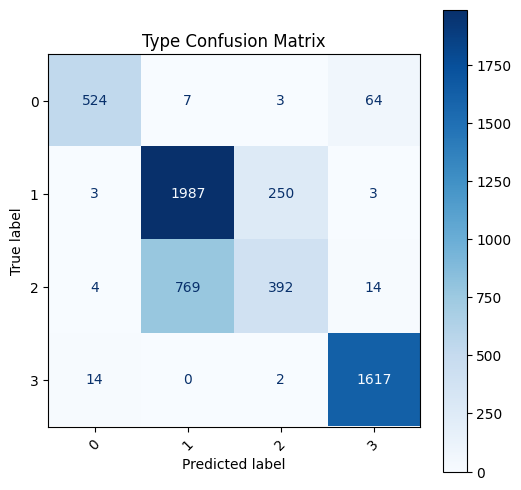

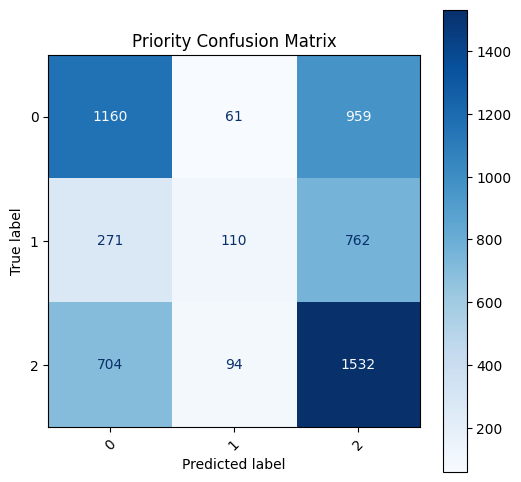

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title(title)
    plt.show()

# TYPE
plot_conf_matrix(y_test_type, type_model.predict(X_test), "Type Confusion Matrix")

# PRIORITY
plot_conf_matrix(y_test_priority, priority_model.predict(X_test), "Priority Confusion Matrix")

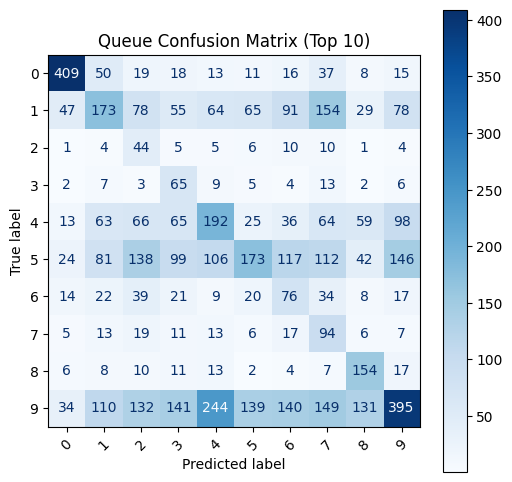

In [52]:
top_queues = train_df['queue'].value_counts().head(10).index

mask = test_df['queue'].isin(top_queues)

y_true_top = y_test_queue[mask]
y_pred_top = queue_model.predict(X_test[mask])

plot_conf_matrix(y_true_top, y_pred_top, "Queue Confusion Matrix (Top 10)")

In [53]:
from sklearn.metrics import classification_report

def print_class_report(y_true, y_pred, title):
    print(f"\n===== {title} =====\n")
    print(classification_report(y_true, y_pred))

# TYPE
print_class_report(y_test_type, type_model.predict(X_test), "TYPE REPORT")

# PRIORITY
print_class_report(y_test_priority, priority_model.predict(X_test), "PRIORITY REPORT")

# QUEUE
print_class_report(y_test_queue, queue_model.predict(X_test), "QUEUE REPORT")


===== TYPE REPORT =====

              precision    recall  f1-score   support

      Change       0.96      0.88      0.92       598
    Incident       0.72      0.89      0.79      2243
     Problem       0.61      0.33      0.43      1179
     Request       0.95      0.99      0.97      1633

    accuracy                           0.80      5653
   macro avg       0.81      0.77      0.78      5653
weighted avg       0.79      0.80      0.78      5653


===== PRIORITY REPORT =====

              precision    recall  f1-score   support

        high       0.54      0.53      0.54      2180
         low       0.42      0.10      0.16      1143
      medium       0.47      0.66      0.55      2330

    accuracy                           0.50      5653
   macro avg       0.48      0.43      0.41      5653
weighted avg       0.49      0.50      0.47      5653


===== QUEUE REPORT =====

                                 precision    recall  f1-score   support

           Billing and Paym

# Semantic retrival

In [32]:
!pip install sentence-transformers

In [33]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
train_embeddings = embed_model.encode(train_df['text_clean'], show_progress_bar=True)

Batches:   0%|          | 0/707 [00:00<?, ?it/s]

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve_best_answer(query):
    query_emb = embed_model.encode([query])
    sims = cosine_similarity(query_emb, train_embeddings)[0]

    top_idx = sims.argmax()
    best_match = train_df.iloc[top_idx]

    return {
        "similarity_score": float(sims[top_idx]),
        "matched_text": best_match['text_clean'],
        "answer": best_match['answer']
    }

In [41]:
def predict_ticket(text):
    text_clean = text.lower()

    vec = embed_model.encode([text_clean])

    best_match = retrieve_best_answer(text)

    result = {
        "type": type_model.predict(vec)[0],
        "priority": priority_model.predict(vec)[0],
        "queue": queue_model.predict(vec)[0],
        "tags": mlb.inverse_transform(tag_model.predict(vec))[0],
        "best_match": best_match
    }

    return result

In [42]:
def pretty_print_prediction(result, query):
    print("\n===== YOUR QUERY =====\n")
    print(query)

    print("\n===== PREDICTION =====\n")
    print(f"Type      : {result['type']}")
    print(f"Priority  : {result['priority']}")
    print(f"Queue     : {result['queue']}")
    print(f"Tags      : {', '.join(result['tags'])}")

    print("\n===== MATCHED PAST CASE =====\n")
    print(result['best_match']['matched_text'])

    print("\n===== SUGGESTED RESPONSE =====\n")
    print(result['best_match']['answer'])

    print("\n===== CONFIDENCE =====")
    print(f"Similarity Score: {result['best_match']['similarity_score']:.3f}")

In [50]:
sample_text = test_df.loc[2089, 'text_clean']

result = predict_ticket(sample_text)

pretty_print_prediction(result, sample_text)


===== YOUR QUERY =====

challenges with alteryx woocommerce data integration facing difficulties with data integration between platforms

===== PREDICTION =====

Type      : Incident
Priority  : high
Queue     : Sales and Pre-Sales
Tags      : Documentation

===== MATCHED PAST CASE =====

trouble with alteryx woocommerce data integration facing data integration problems between platforms

===== SUGGESTED RESPONSE =====

The <name> Service Desk team is addressing the Alteryx WooCommerce data integration issue. Please share the details of the issue, any error messages, or data you're receiving, so we can better understand the problem and provide an effective solution. Could you also schedule a call at a convenient time for you to discuss the issue further?

===== CONFIDENCE =====
Similarity Score: 0.978
